In [17]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src/')
import importlib

In [18]:
import Cosmology as cosmo
import Constants_Units as cu
import Alternat_XRaySources as axs
from Theoretical_Setup import z_range

In [30]:
importlib.reload(cosmo)
importlib.reload(cu)
importlib.reload(axs)

<module 'Alternat_XRaySources' from '/home/brokrab/Documents/GalaxyFormation_MegaDirectory/Galaxy_Formation_Research/Global_Reionization_History/Notebooks/../src/Alternat_XRaySources.py'>

# Accretion Shocks

In [3]:
def accretion_emissivityPerEnergy(E, z_initial):
    return E ** (-1) / (1 + z_initial) ** 3

In [8]:
gamma_min = 10 ** 2 #Least upscattering gamma
gamma_max = 10 ** 3 #Highest upscattering gamma

def Initial_CMB_energy(z): #CMB photon energy before upscattering event
    T_0 = 2.725 #K
    E_mean_0 = 2.701 * (cu.k_B * cu.JToerg) * T_0 #Mean CMB energy today in erg
    return E_mean_0 * (1 + z)

z_in_arr = z_range #Upscattering redshift range

Initial_CMB_energy_arr = Initial_CMB_energy(z_in_arr)

def Upscattered_Energy(Initial_Energy, Gamma_val): #CMB photon energy after IC Upscattering
    return 4 / 3 * Gamma_val ** 2 * Initial_Energy

E_min_arr = Upscattered_Energy(Initial_CMB_energy_arr, gamma_min) #Upscattered energy corresponding to gamma_min
E_max_arr = Upscattered_Energy(Initial_CMB_energy_arr, gamma_max) #Upscattered energy corresponding to gamma_max

In [9]:
EmPerEn_integral = np.zeros(len(z_in_arr))

E_Int_StepCount = 1000

EmPerEn_vals = np.zeros((len(z_in_arr), E_Int_StepCount))
E_ranges = np.zeros((len(z_in_arr), E_Int_StepCount))

for i, z in enumerate(z_in_arr):

    E_range = np.linspace(
        E_min_arr[i],
        E_max_arr[i],
        E_Int_StepCount
    )

    emissivityPerEn = accretion_emissivityPerEnergy(E_range, z)

    E_ranges[i] = E_range
    EmPerEn_vals[i] = emissivityPerEn

    EmPerEn_integral[i] = np.trapezoid(
        emissivityPerEn,
        x=E_range
    )

Text(0.5, 1.0, 'Unnormalized Bolometric Emissivity vs Redshift')

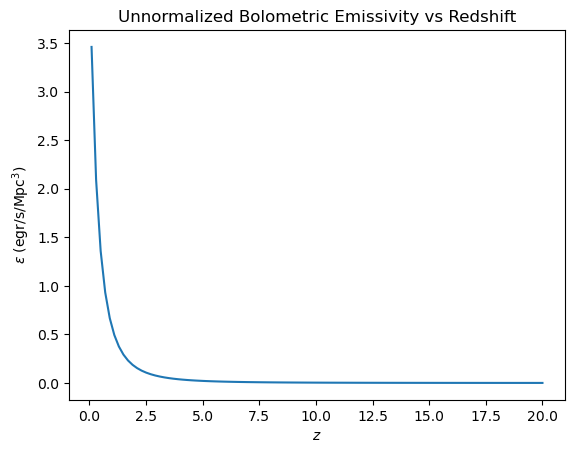

In [10]:
plt.plot(z_range, EmPerEn_integral)
plt.xlabel(r'$z$')
plt.ylabel(r'$\epsilon$ (egr/s/Mpc$^3$)')
plt.title(r'Unnormalized Bolometric Emissivity vs Redshift')

In [14]:
EmmPerEn_Norm = axs.AccShocks_Em_vals / EmPerEn_integral #Finding the normalization of the emissivity per unit energy

In [15]:
Norm_EmPerEn_integral = EmmPerEn_Norm * EmPerEn_integral #Testing the normalized bolometric emissivity

Text(0.5, 1.0, 'Normalized Bolometric Emissivity vs Redshift')

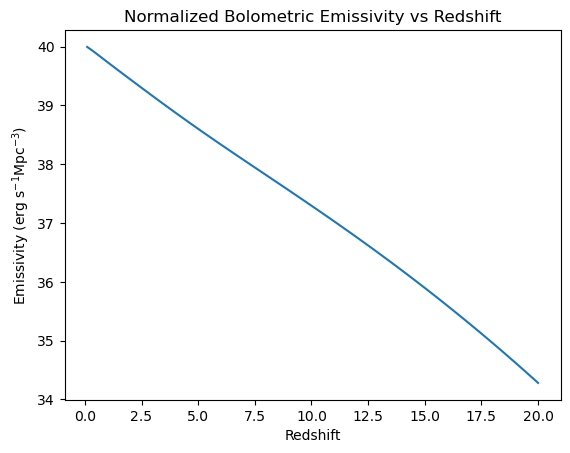

In [16]:
plt.plot(z_in_arr, np.log10(Norm_EmPerEn_integral))
plt.xlabel(r'Redshift')
plt.ylabel(r'Emissivity (erg s$^{-1}$Mpc$^{-3}$)')
plt.title(r'Normalized Bolometric Emissivity vs Redshift')

In [35]:
Norm_EmPerEn_vals = EmPerEn_vals * EmmPerEn_Norm[:, np.newaxis]

E_ranges_keV = E_ranges * cu.ergTokeV

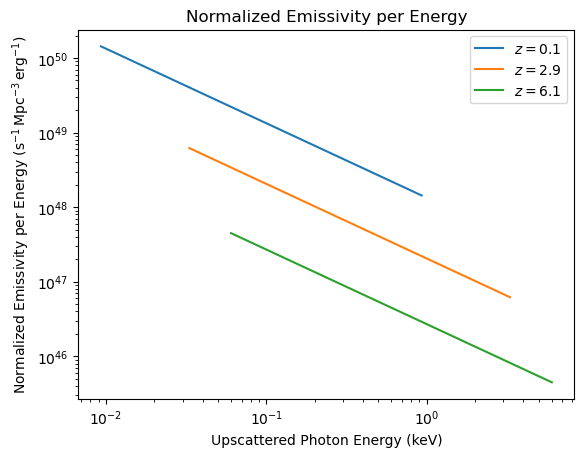

In [36]:
plt.loglog(E_ranges_keV[0],  Norm_EmPerEn_vals[0],  label=fr'$z={z_in_arr[0]:.1f}$')
plt.loglog(E_ranges_keV[14], Norm_EmPerEn_vals[14], label=fr'$z={z_in_arr[14]:.1f}$')
plt.loglog(E_ranges_keV[30], Norm_EmPerEn_vals[30], label=fr'$z={z_in_arr[30]:.1f}$')

plt.xlabel(r'Upscattered Photon Energy (keV)')
plt.ylabel(r'Normalized Emissivity per Energy ($\mathrm{s^{-1}\,Mpc^{-3}\,erg^{-1}}$)')
plt.title(r'Normalized Emissivity per Energy')
plt.legend()

plt.show()

# Quasi-Stellar Objects (QSOs)

In [37]:
def QSO_EmPerNu0(z): # Here Nu0 = c / 1000 A, as given by Khaire and Srianand
    return 4.53 * 10 ** 24 * (1 + z) ** 5.9 * np.e ** (-0.36 * z) / (np.e ** (2.2 * z) + 25.1)

def QSO_Bol_Em(z): # Fit from Khaire and Srianand
    wavelength = 1000 * 10 ** (-10) # in m
    freq = cu.c / wavelength # in hz
    return QSO_EmPerNu0(z) * freq

In [38]:
QSO_Bol_Em_vals = QSO_Bol_Em(z_range)

/tmp/ipykernel_225434/2231089165.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(z_range, np.log10(axs.LMXB_Em_vals), label = r'LMXB')


Text(0.5, 1.0, 'Bolometric Emissivity vs Redshift')

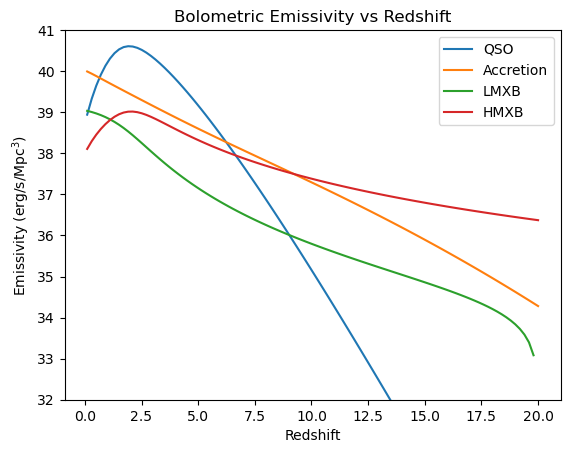

In [39]:
plt.plot(z_range, np.log10(QSO_Bol_Em_vals), label = r'QSO')
plt.plot(z_in_arr, np.log10(Norm_EmPerEn_integral), label = r'Accretion')
plt.plot(z_range, np.log10(axs.LMXB_Em_vals), label = r'LMXB')
plt.plot(z_range, np.log10(axs.HMXB_Em_vals), label = r'HMXB')
plt.ylim(32, 41)
plt.legend()

plt.xlabel(r'Redshift')
plt.ylabel(r'Emissivity (erg/s/Mpc$^3$)')
plt.title(r'Bolometric Emissivity vs Redshift')

In [40]:
def k_nu_Q1(E): # E in eV, k_nu is dimensionless
    A_1 = 2 ** (0.8)
    A_2 = 1
    h_nu_a = 2 * 10 ** 3# in eV, fiducial model adopted
    alpha = -1.8 # Power-law index of k_nu, corresponding to the fiducial model
    A_3 = np.e ** (-12.4 / h_nu_a)
    A_4 = A_3 * np.e ** (1 + h_nu_a / (2 * 10 ** 6)) * (h_nu_a / 12.4) ** alpha
    if E <= 6.2:
        return A_1 * (E / 6.2) ** (-0.5)
    elif E <= 12.4:
        return A_2 * (E / 12.4) ** (-0.8)
    elif E <= h_nu_a:
        return A_3 * (E / 12.4) ** (alpha) * np.e ** (E / h_nu_a)
    else:
        return A_4 * (E / h_nu_a) ** (-0.8) * np.e ** (-E / (2 * 10 ** 6))

In [41]:
def QSO_EmPerNu(E, z): # in erg/s/hz/Mpc^3
    return k_nu_Q1(E) * QSO_EmPerNu0(z)

def QSO_EmPerE(E, z): # in /s Mpc^3
    return QSO_EmPerNu(E, z) / cu.h_p

In [42]:
Test_nu_ranges = E_ranges_keV / (cu.h_p * cu.ergTokeV)

QSO_EmPerNu_arr = np.zeros_like(E_ranges_keV)
Nu_QSO_EmPerNu_arr = np.zeros_like(E_ranges_keV)

for i in range(len(z_range)):
    for j in range(E_ranges_keV.shape[1]):
        QSO_EmPerNu_arr[i, j] = QSO_EmPerNu(
            E_ranges_keV[i, j] * 1000,  # keV -> eV
            z_range[i]
        )

        Nu_QSO_EmPerNu_arr[i, j] = (
            QSO_EmPerNu_arr[i, j]
            * Test_nu_ranges[i, j]
        )

Text(0.5, 1.0, '$\\nu\\epsilon_\\nu$ vs $E$ at $z=0$')

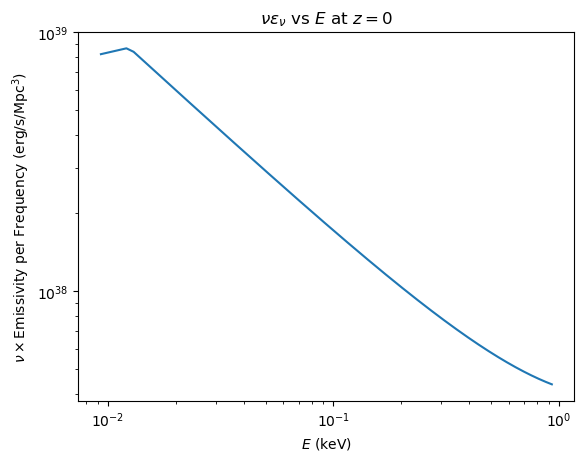

In [43]:
plt.loglog(E_ranges_keV[0], Nu_QSO_EmPerNu_arr[0])
plt.xlabel(r'$E$ (keV)')
plt.ylabel(r'$\nu\times$Emissivity per Frequency (erg/s/Mpc$^3$)')
plt.title(r'$\nu\epsilon_\nu$ vs $E$ at $z=0$')

#plt.axvline(10**(-1))
#plt.axhline(1.7*10**(38))

In [44]:
QSO_EmPerE_arr = np.zeros_like(E_ranges_keV)

for i in range(len(z_range)):
    for j in range(E_ranges_keV.shape[1]):
        QSO_EmPerE_arr[i, j] = QSO_EmPerE(
            E_ranges_keV[i, j] * 1000,  # keV -> eV
            z_range[i]
        )

Text(0.5, 1.0, 'Emissivity per Energy at $z=6$')

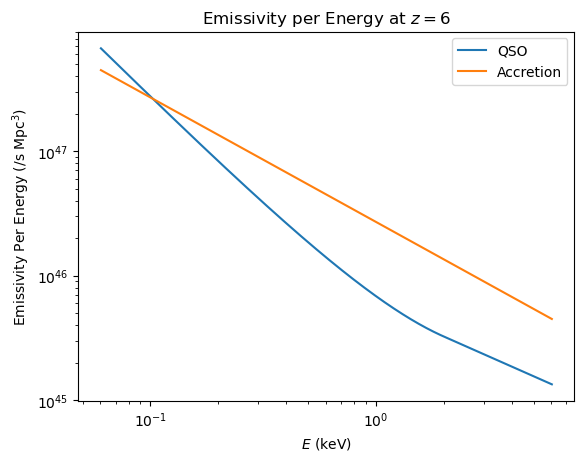

In [45]:
plt.loglog(E_ranges_keV[30], QSO_EmPerE_arr[30], label = r'QSO')
plt.loglog(E_ranges_keV[30], Norm_EmPerEn_vals[30], label = r'Accretion')
plt.xlabel(r'$E$ (keV)')
plt.ylabel(r'Emissivity Per Energy (/s Mpc$^3$)')
plt.legend()
plt.title(r'Emissivity per Energy at $z=6$')

# Varying $f_\text{R}$

In [46]:
EmmPerEn_Norm_2 = axs.AccShocks_Em_vals_2 / EmPerEn_integral #Finding the normalization of the emissivity per unit energy
EmmPerEn_Norm_3 = axs.AccShocks_Em_vals_3 / EmPerEn_integral #Finding the normalization of the emissivity per unit energy

In [47]:
Norm_EmPerEn_integral_2 = EmmPerEn_Norm_2 * EmPerEn_integral #Testing the normalized bolometric emissivity
Norm_EmPerEn_integral_3 = EmmPerEn_Norm_3 * EmPerEn_integral #Testing the normalized bolometric emissivity

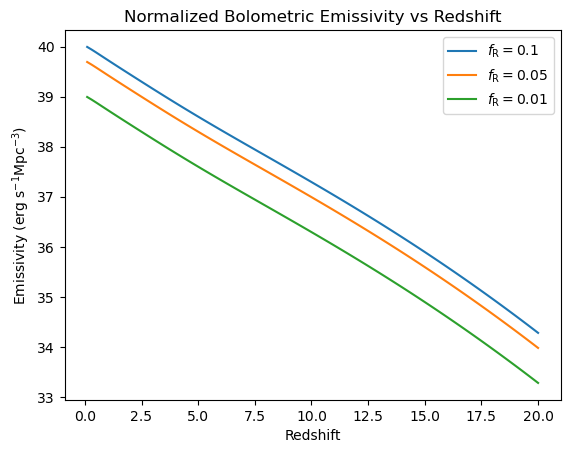

In [48]:
plt.plot(z_in_arr, np.log10(Norm_EmPerEn_integral), label = r'$f_\text{R}=0.1$')
plt.plot(z_in_arr, np.log10(Norm_EmPerEn_integral_2), label = r'$f_\text{R}=0.05$')
plt.plot(z_in_arr, np.log10(Norm_EmPerEn_integral_3), label = r'$f_\text{R}=0.01$')
plt.xlabel(r'Redshift')
plt.ylabel(r'Emissivity (erg s$^{-1}$Mpc$^{-3}$)')
plt.title(r'Normalized Bolometric Emissivity vs Redshift')

plt.legend()

In [49]:
Norm_EmPerEn_vals_2 = EmPerEn_vals * EmmPerEn_Norm_2[:, None]

Norm_EmPerEn_vals_3 = EmPerEn_vals * EmmPerEn_Norm_3[:, None]

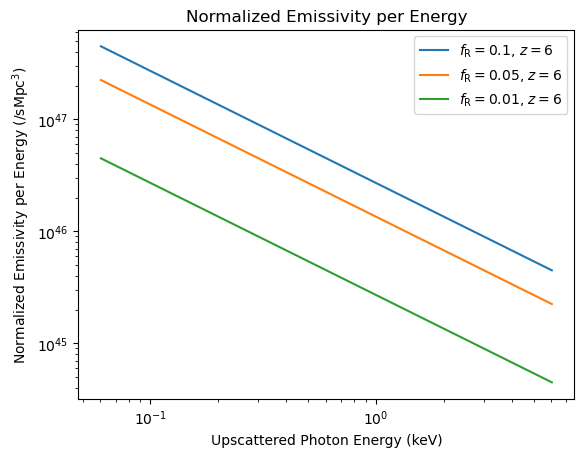

In [50]:
plt.loglog(E_ranges_keV[30], Norm_EmPerEn_vals[30], label = r'$f_\text{R}=0.1$, $z=6$')
plt.loglog(E_ranges_keV[30], Norm_EmPerEn_vals_2[30], label = r'$f_\text{R}=0.05$, $z=6$')
plt.loglog(E_ranges_keV[30], Norm_EmPerEn_vals_3[30], label = r'$f_\text{R}=0.01$, $z=6$')
plt.xlabel(r'Upscattered Photon Energy (keV)')
plt.ylabel(r'Normalized Emissivity per Energy (/sMpc$^3$)')
plt.title(r'Normalized Emissivity per Energy')
plt.legend()

/tmp/ipykernel_225434/3859130075.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.plot(z_range, np.log10(axs.LMXB_Em_vals), label = r'LMXB', ls = '--')


Text(0.5, 1.0, 'Bolometric Emissivity vs Redshift')

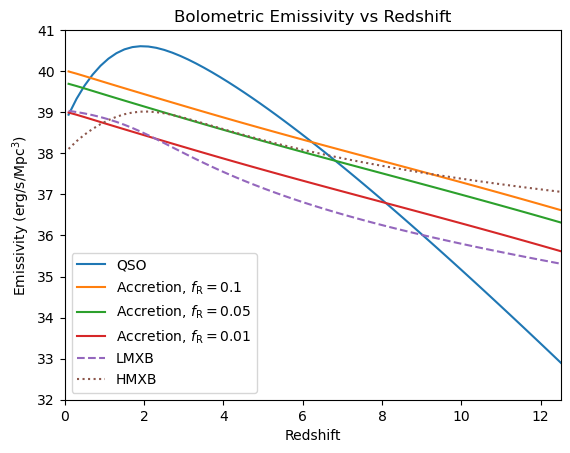

In [52]:
plt.plot(z_range, np.log10(QSO_Bol_Em_vals), label = r'QSO')
plt.plot(z_in_arr, np.log10(Norm_EmPerEn_integral), label = r'Accretion, $f_\text{R}=0.1$')
plt.plot(z_in_arr, np.log10(Norm_EmPerEn_integral_2), label = r'Accretion, $f_\text{R}=0.05$')
plt.plot(z_in_arr, np.log10(Norm_EmPerEn_integral_3), label = r'Accretion, $f_\text{R}=0.01$')
plt.plot(z_range, np.log10(axs.LMXB_Em_vals), label = r'LMXB', ls = '--')
plt.plot(z_range, np.log10(axs.HMXB_Em_vals), label = r'HMXB', ls = ':')
plt.ylim(32, 41)
plt.xlim(0, 12.5)
plt.legend()

plt.xlabel(r'Redshift')
plt.ylabel(r'Emissivity (erg/s/Mpc$^3$)')
plt.title(r'Bolometric Emissivity vs Redshift')

Text(0.5, 1.0, 'Emissivity per Energy at $z=6$')

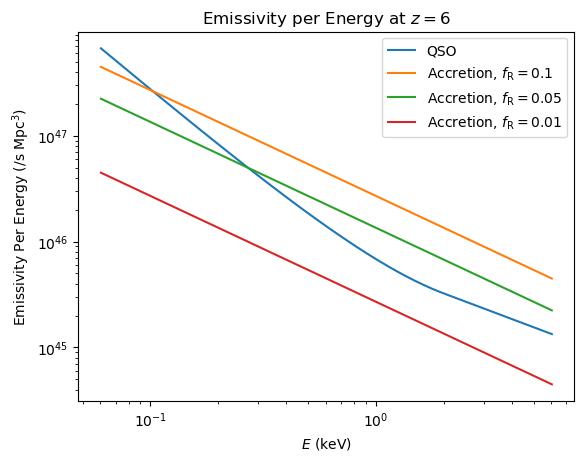

In [53]:
plt.loglog(E_ranges_keV[30], QSO_EmPerE_arr[30], label = r'QSO')
plt.loglog(E_ranges_keV[30], Norm_EmPerEn_vals[30], label = r'Accretion, $f_\text{R}=0.1$')
plt.loglog(E_ranges_keV[30], Norm_EmPerEn_vals_2[30], label = r'Accretion, $f_\text{R}=0.05$')
plt.loglog(E_ranges_keV[30], Norm_EmPerEn_vals_3[30], label = r'Accretion, $f_\text{R}=0.01$')
plt.xlabel(r'$E$ (keV)')
plt.ylabel(r'Emissivity Per Energy (/s Mpc$^3$)')
plt.legend()
plt.title(r'Emissivity per Energy at $z=6$')